### A Quantum simulation to generate Random Numbers


In [53]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def quantum_random_number(n_bits):
    qc = QuantumCircuit(n_bits, n_bits)

    # Put all qubits in superposition
    for i in range(n_bits):
        qc.h(i)

    qc.measure(range(n_bits), range(n_bits))

    simulator = AerSimulator()
    job = simulator.run(qc, shots=1)
    result = job.result()
    counts = result.get_counts()

    binary = list(counts.keys())[0]
    return int(binary, 2), qc

number, circuit = quantum_random_number(3)
print(f"Quantum number: {number}")
print(circuit.draw())

Quantum number: 2
     ┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     ├───┤└╥┘┌─┐   
q_1: ┤ H ├─╫─┤M├───
     ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 3/══════╩══╩══╩═
           0  1  2 


### Plotting of Random Numbers
## The Program runs 1000 times or 1000 numbers are randomly genrated in an 8-bit system

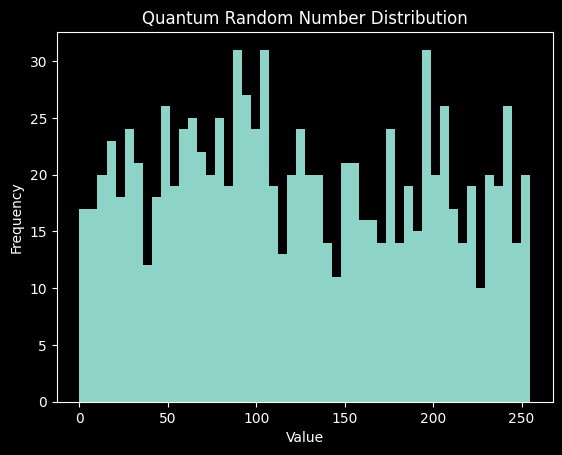

In [54]:
import matplotlib.pyplot as plt

results = [quantum_random_number(8)[0] for _ in range(1000)]
plt.hist(results, bins=50)
plt.title("Quantum Random Number Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.savefig("distribution.png")
plt.show()

### A program to generate random numbers through Classical Computer

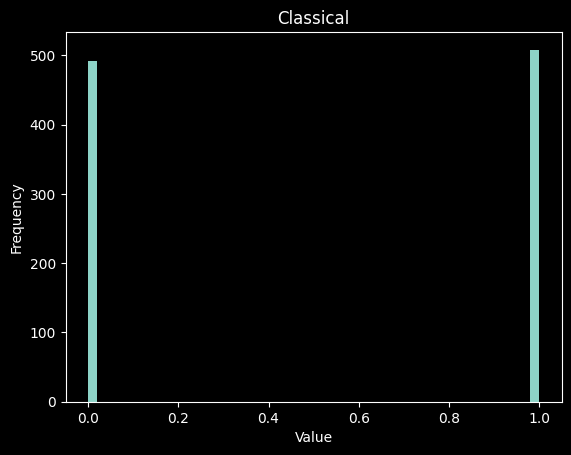

In [61]:
import random
import matplotlib.pyplot as plt
classical = [random.randint(0, 1) for _ in range(1000)]
plt.hist(classical, bins=50)
plt.title("Classical")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()